# Phase 6 - Model Evaluation & Comparison

## Objective

The objective of this phase is to evaluate the performance of all regression models using the same test dataset and identify the best-performing model.

### Evaluation Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score
- Adjusted R²
- Cross Validation Score

### Visualizations

- Actual vs Predicted
- Residual Plot
- Prediction Error Plot
- Feature Importance
- Model Comparison Chart

### Expected Outcome

Select the best regression model for deployment in the Flask web application.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
df=pd.read_csv("/home/aximsoft/Documents/AximSoft_EOWA/Week_08/Notebooks/dataset/house_prices_cleaned.csv")

df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,HouseAge,TotalBathrooms,TotalSF,TotalPorchArea,RemodeledHouse
0,1,4.110874,4.189655,9.042040,7,5,2003,2003,5.283204,6.561031,...,0,0,0,1,0,5,3.500000,20.257977,4.127134,0
1,2,3.044522,4.394449,9.169623,6,8,1976,1976,0.000000,6.886532,...,0,0,0,1,0,31,2.346574,14.282490,0.000000,0
2,3,4.110874,4.234107,9.328212,7,5,2001,2002,5.093750,6.188264,...,0,0,0,1,0,7,3.500000,20.415959,3.761200,1
3,4,4.262680,4.110874,9.164401,7,5,1915,1970,0.000000,5.379897,...,0,0,0,0,0,91,2.000000,20.127741,9.192991,1
4,5,4.110874,4.442651,9.565284,8,5,2000,2000,5.860786,6.486161,...,0,0,0,1,0,8,3.500000,21.048414,4.442651,0


In [3]:
# Import Libraries
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
# Features and Target
features = [
    "OverallQual",     # Overall material and finish quality
    "GrLivArea",       # Above ground living area
    "GarageCars",      # Garage capacity
    "TotalBsmtSF",     # Total basement area
    "FullBath",        # Number of full bathrooms
    "YearBuilt",       # Construction year
    "1stFlrSF",        # First floor area
    "TotRmsAbvGrd",    # Total rooms above ground
    "Fireplaces",      # Number of fireplaces
    "LotArea"          # Total lot size
]
X = df[features]
y = df["SalePrice"]

In [5]:
# Train Test Split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Load Best Model
model=joblib.load("/home/aximsoft/Documents/AximSoft_EOWA/Week_08/Notebooks/dataset/models/best_model.pkl")

In [7]:
# Prediction
prediction=model.predict(X_test)

In [8]:
# MAE
mae=mean_absolute_error(y_test,prediction)
print("MAE :",mae)

MAE : 15999.499865975351


In [9]:
# MSE
mse=mean_squared_error(y_test,prediction)
print("MSE :",mse)

MSE : 470258474.3120539


In [10]:
# RMSE
rmse=np.sqrt(mse)
print("RMSE :",rmse)

RMSE : 21685.443834795125


In [11]:
# R2 Score
r2=r2_score(y_test,prediction)
print("R2 Score :",r2)

R2 Score : 0.852157978425293


In [12]:
# Adjusted R2
n=len(y_test)
p=X_test.shape[1]

adjusted_r2=1-(1-r2)*(n-1)/(n-p-1)

print("Adjusted R2 :",adjusted_r2)

Adjusted R2 : 0.8466619924931478


In [13]:
# Cross Validation
from sklearn.model_selection import cross_val_score

score=cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(score)
print("Average Cross Validation :",score.mean())

[0.84513235 0.8749093  0.85361629 0.86335237 0.83569015]
Average Cross Validation : 0.8545400928723351


In [14]:
# Evaluation Summary
evaluation = pd.DataFrame({

    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score",
        "Adjusted R2",
        "Cross Validation"
    ],

    "Value": [
        mae,
        mse,
        rmse,
        r2,
        adjusted_r2,
        score.mean()
    ]

})

evaluation

,Metric,Value
0,MAE,1.599950e+04
1,MSE,4.702585e+08
2,RMSE,2.168544e+04
3,R2 Score,8.521580e-01
4,Adjusted R2,8.466620e-01
5,Cross Validation,8.545401e-01


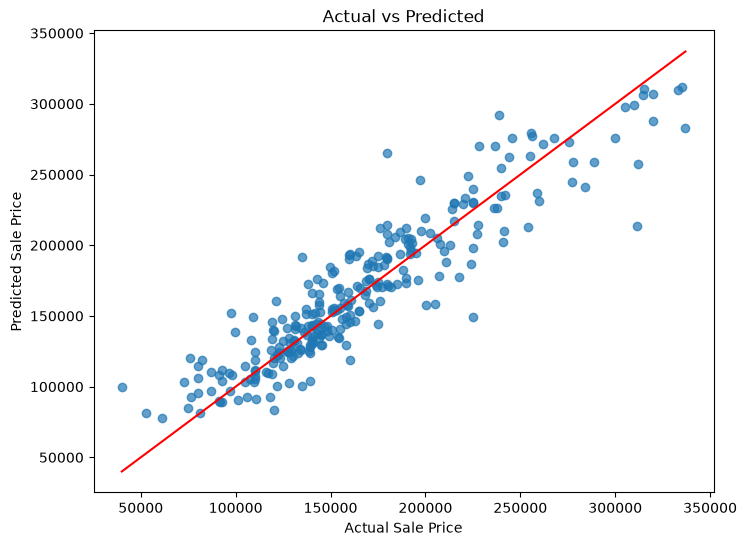

In [15]:
# Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(y_test, prediction, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted")

plt.show()

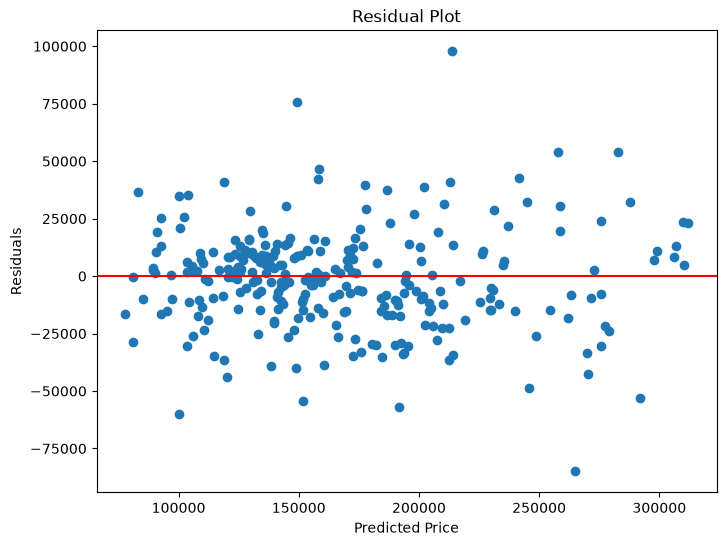

In [16]:
# Residual Plot
residuals = y_test - prediction

plt.figure(figsize=(8,6))

plt.scatter(prediction, residuals)

plt.axhline(0, color="red")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

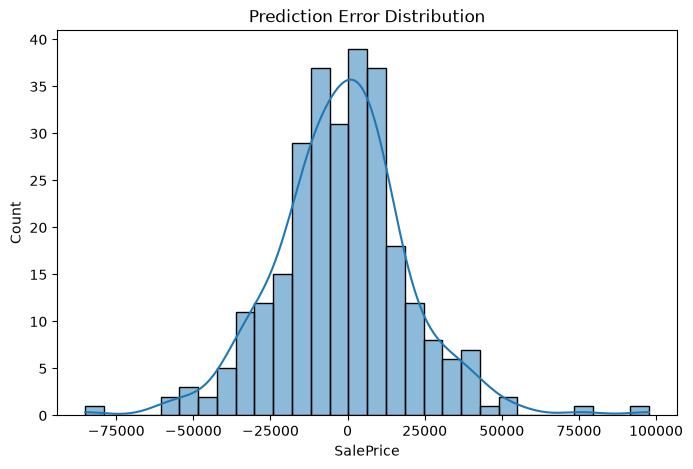

In [17]:
# Prediction Error Distribution
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Prediction Error Distribution")

plt.show()

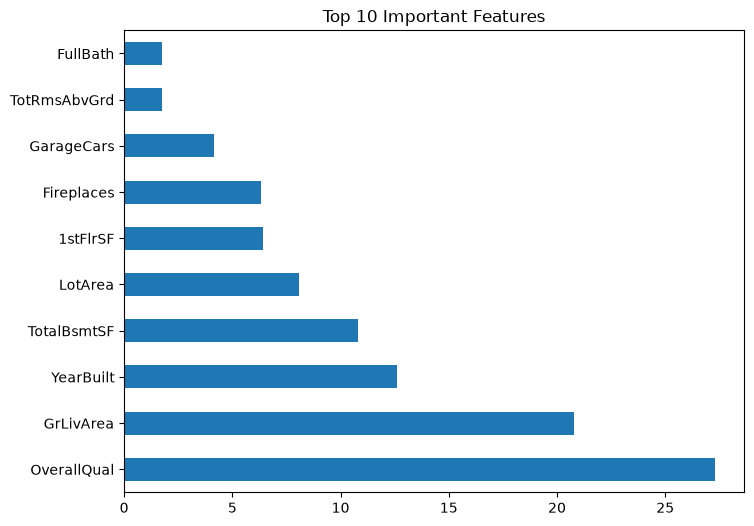

In [18]:
# Feature Importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 10 Important Features")

plt.show()

In [19]:

comparison = pd.read_csv("/home/aximsoft/Documents/AximSoft_EOWA/Week_08/Notebooks/dataset/reports/model_comparison.csv")

comparison


,Model,MAE,MSE,RMSE,R2 Score
0,CatBoost,11480.855107,2.794843e+08,16717.783610,0.912134
1,Gradient Boosting,13284.836044,3.576519e+08,18911.687912,0.887560
2,LightGBM,13469.373309,3.833403e+08,19579.078554,0.879484
3,XGBoost,14013.219727,4.109945e+08,20272.999975,0.870790
4,Random Forest,14043.607250,4.354628e+08,20867.744897,0.863097
5,Decision Tree,23677.432143,1.172576e+09,34242.902612,0.631360
6,Linear Regression,16837.207398,1.191990e+09,34525.206485,0.625257


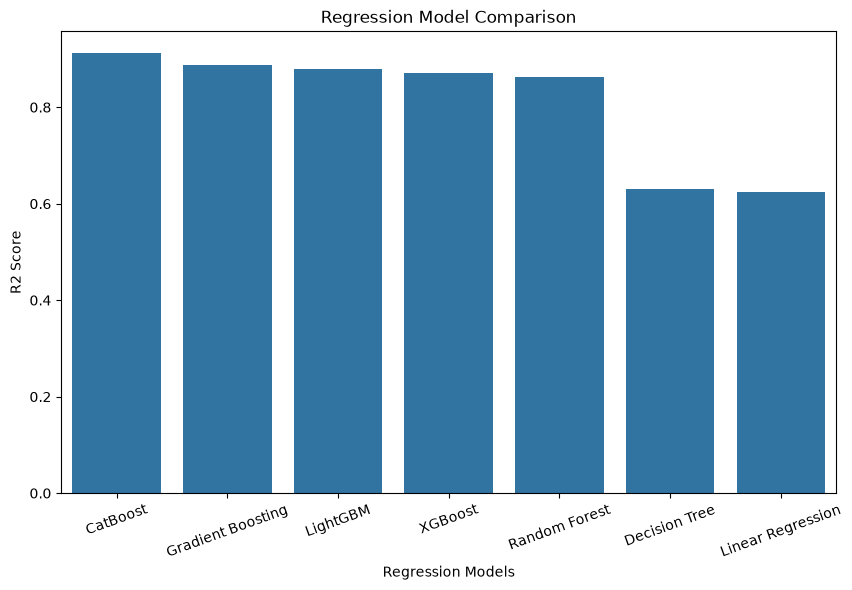

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.xticks(rotation=20)

plt.title("Regression Model Comparison")

plt.xlabel("Regression Models")
plt.ylabel("R2 Score")

plt.show()

In [22]:
# Best Model
print("Best Model : CatBoostRegressor")
print("R2 Score :", r2)
print("Cross Validation :", score.mean())

Best Model : CatBoostRegressor
R2 Score : 0.852157978425293
Cross Validation : 0.8545400928723351
